# EDA Notebook for Race Data
This notebook explores the cleaned race data. We analyze distributions, correlations, top riders, and point-based metrics. Each plot is accompanied by descriptive statistics and observations.

In [10]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")

In [11]:
# Load data
data_path = "../phase2/processed_data/race_data_processed_v3.csv"
df = pd.read_csv(data_path, parse_dates=['Date','birthdate'])
print(f"Data shape: {df.shape}")
df.head()

Data shape: (151746, 56)


,Timelag,Rider,Age,Team,Time,Race_Name,Stage_Name,Date,Stage_Type,Start,...,Pnt_race_count,Pnt_points_per_race,age_at_race,race_tier,rolling_avg_rank_5,rolling_avg_rank_10,recent_top10_count,recent_top10_rate,Timelag_sec,Time_sec
0,+0:10,AAEN JØRGENSEN Jonas,25,Team Saxo Bank - Tinkoff Bank,0:00,Santos Tour Down Under,Stage 1 | Prospect-Clare,2012-01-17,RR,Prospect,...,4,6.75,25.744011,3,89.00,89.00,0.0,0.0,10,0
1,+3:05,AAEN JØRGENSEN Jonas,25,Team Saxo Bank - Tinkoff Bank,3:55,Santos Tour Down Under,Stage 2 | Lobethal-Stirling,2012-01-18,RR,Lobethal,...,4,6.75,25.746749,3,86.00,86.00,0.0,0.0,185,235
2,+3:13,AAEN JØRGENSEN Jonas,25,Team Saxo Bank - Tinkoff Bank,0:00,Santos Tour Down Under,Stage 3 | Unley-Victor Harbor,2012-01-19,RR,Unley,...,4,6.75,25.749487,3,82.00,82.00,0.0,0.0,193,0
3,+17:21,AAEN JØRGENSEN Jonas,25,Team Saxo Bank - Tinkoff Bank,14:16,Santos Tour Down Under,Stage 4 | Norwood-Tanunda,2012-01-20,RR,Norwood,...,4,6.75,25.752225,3,93.25,93.25,0.0,0.0,1041,856
4,+22:50,AAEN JØRGENSEN Jonas,25,Team Saxo Bank - Tinkoff Bank,5:31,Santos Tour Down Under,Stage 5 | McLaren-Old Willunga Hill,2012-01-21,RR,McLaren,...,4,6.75,25.754962,3,84.60,84.60,0.0,0.0,1370,331


## Overview and Missing Values

In [12]:
display(df.info())

missing_pct = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print("Missing values (% of dataset):")
display(missing_pct[missing_pct>0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151746 entries, 0 to 151745
Data columns (total 56 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Timelag                          134129 non-null  object        
 1   Rider                            151746 non-null  object        
 2   Age                              151746 non-null  int64         
 3   Team                             151746 non-null  object        
 4   Time                             143054 non-null  object        
 5   Race_Name                        151746 non-null  object        
 6   Stage_Name                       151746 non-null  object        
 7   Date                             136190 non-null  datetime64[ns]
 8   Stage_Type                       151746 non-null  object        
 9   Start                            151746 non-null  object        
 10  Finish                           151746 non-

None

Missing values (% of dataset):


birthdate    25.382547
Timelag      11.609532
Date         10.251341
Time          5.727993
Pnt_std       0.081057
UCI_std       0.081057
dtype: float64

Observations:
- Most columns are complete.
- `birthdate` and `country` have ~23% missing.
- Rolling metrics and ranks are precomputed.
- Missing birthdates may affect `age_at_race`.

## Target Variable Analysis (`is_top_10`)

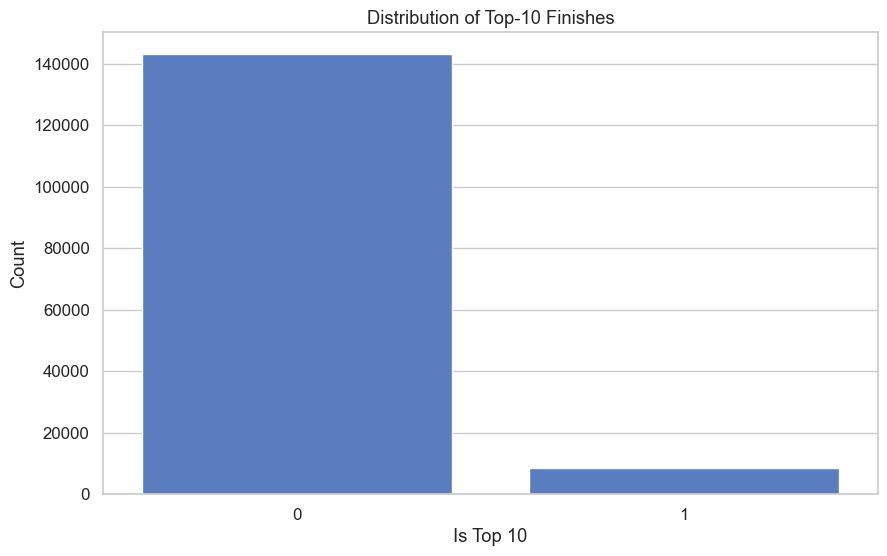

Counts:
is_top_10
0    143111
1      8635
Name: count, dtype: int64

Percentages:
is_top_10
0    94.30957
1     5.69043
Name: proportion, dtype: float64


In [13]:
sns.countplot(x='is_top_10', data=df)
plt.title("Distribution of Top-10 Finishes")
plt.xlabel("Is Top 10")
plt.ylabel("Count")
plt.show()

counts = df['is_top_10'].value_counts()
percentages = df['is_top_10'].value_counts(normalize=True)*100
print("Counts:")
print(counts)
print("\nPercentages:")
print(percentages)

Observations:
- Only ~6% of entries are top-10 finishes.
- The target is highly imbalanced, which may affect modeling.

## Numeric Features Summary

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,151746.0,27.999453,4.287124,18.0,25.000000,28.000000,31.000000,45.000000
Race_ID,151746.0,17.473844,8.623604,0.0,13.000000,18.000000,23.000000,37.000000
Stage_Number,151746.0,7.030689,5.720624,1.0,2.000000,5.000000,10.000000,21.000000
Rnk_clean,151746.0,135.689995,221.201740,1.0,44.000000,85.000000,127.000000,1007.000000
is_top_10,151746.0,0.056904,0.231660,0.0,0.000000,0.000000,0.000000,1.000000
Length_km,151746.0,167.204183,54.626906,6.0,152.000000,176.500000,198.500000,305.000000
has_uci_points,151746.0,0.044054,0.205216,0.0,0.000000,0.000000,0.000000,1.000000
has_race_points,151746.0,0.123483,0.328992,0.0,0.000000,0.000000,0.000000,1.000000
UCI_filled,151746.0,1.469086,14.204911,0.0,0.000000,0.000000,0.000000,500.000000
Pnt_filled,151746.0,1.927148,10.087085,0.0,0.000000,0.000000,0.000000,275.000000


Observations:
- `Rnk_clean`, `Length_km`, `Time_sec`, `Timelag_sec` have wide ranges and some outliers.
- `age_at_race` mostly ranges between 18–40.
- Rolling metrics are precomputed and ready for analysis.

## Numeric Features Plots with Descriptions

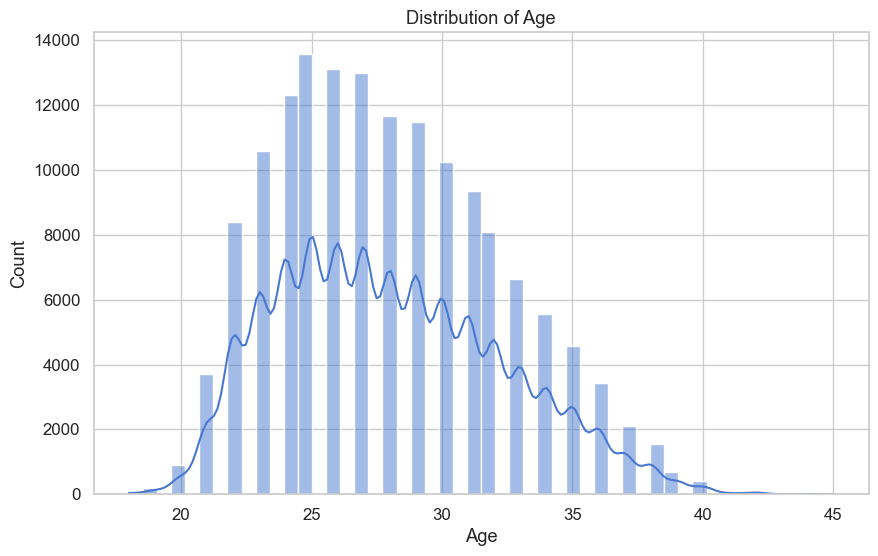

Age statistics:
Mean: 28.00, Median: 28.00, Min: 18.0, Max: 45.0, Std: 4.29
Most riders are between 18 and 40 years old.



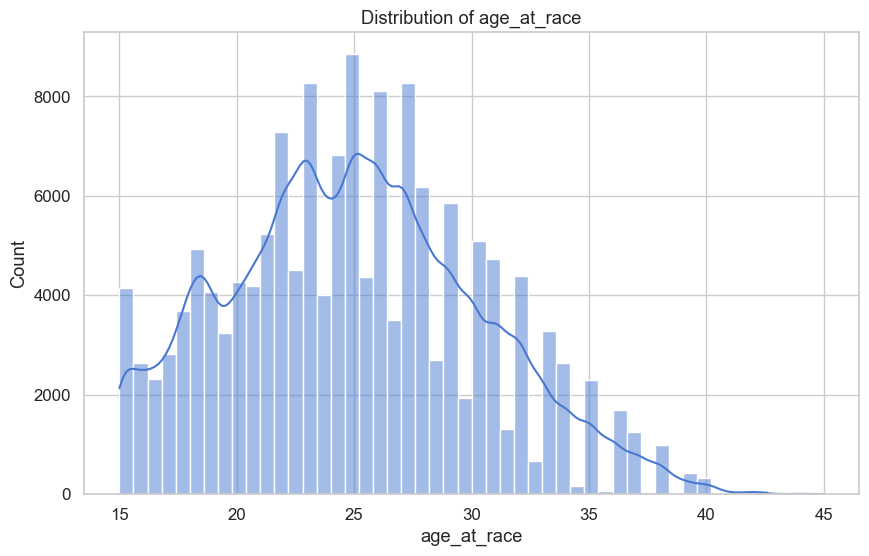

age_at_race statistics:
Mean: 25.00, Median: 25.00, Min: 15.0, Max: 45.0, Std: 5.37
Most riders are between 18 and 40 years old.



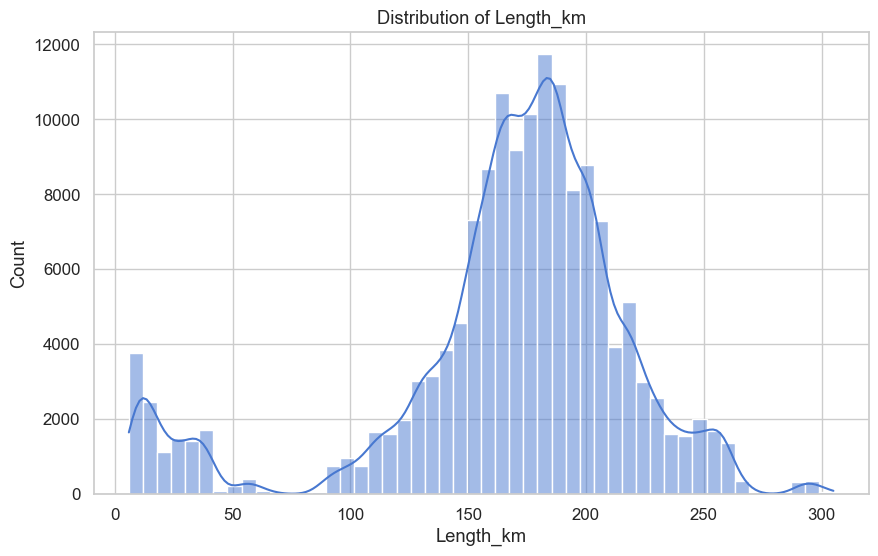

Length_km statistics:
Mean: 167.20, Median: 176.50, Min: 6.0, Max: 305.0, Std: 54.63
Stage lengths vary widely, from 6.0 km to 305.0 km, mean 167.2 km.



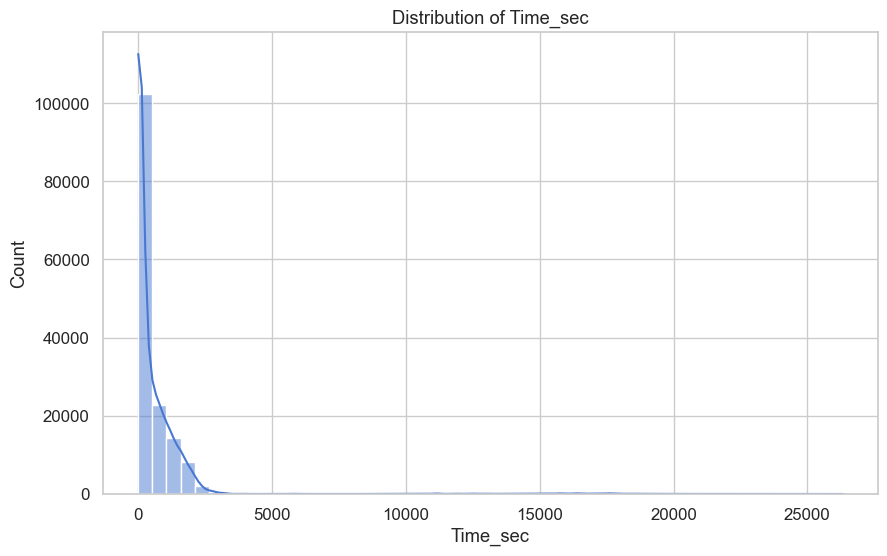

Time_sec statistics:
Mean: 580.50, Median: 166.00, Min: 0.0, Max: 26323.0, Std: 1508.29
Time distributions have long tails; median is 166 sec, mean 581 sec.



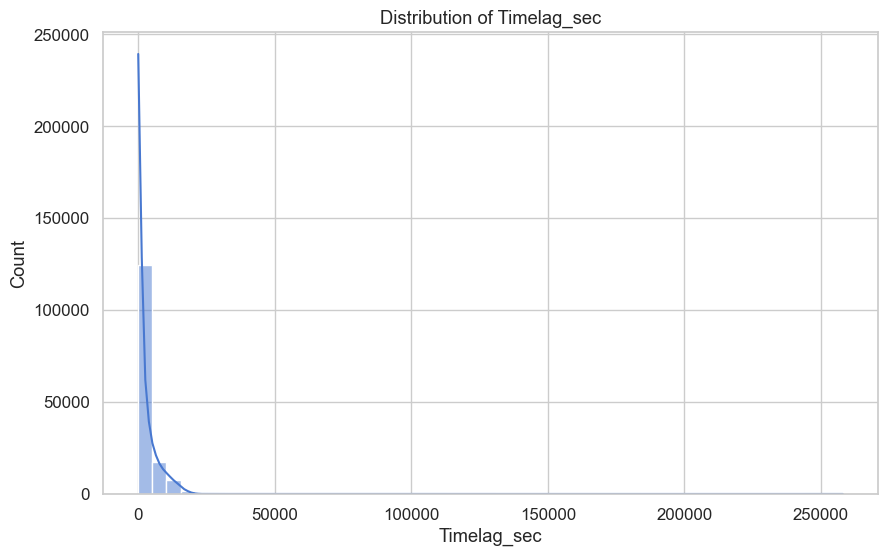

Timelag_sec statistics:
Mean: 2808.07, Median: 918.00, Min: 0.0, Max: 258049.0, Std: 6518.94
Time distributions have long tails; median is 918 sec, mean 2808 sec.



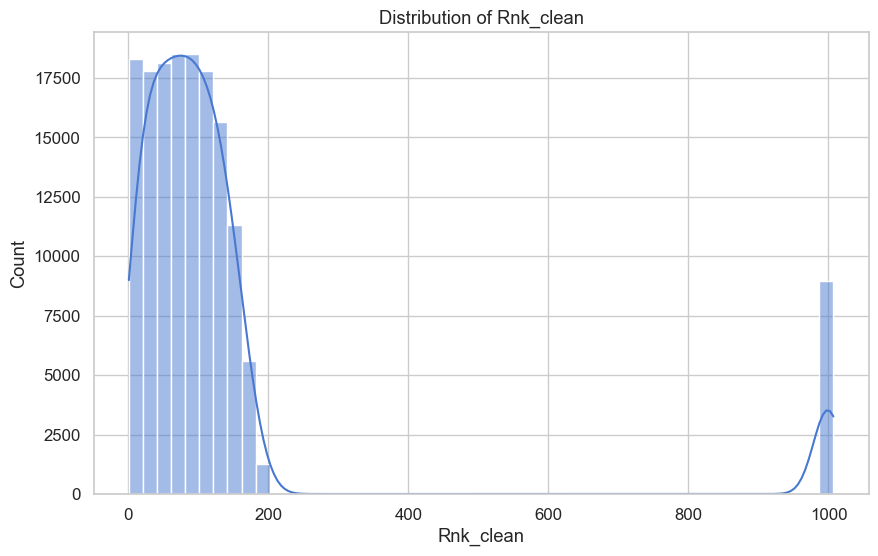

Rnk_clean statistics:
Mean: 135.69, Median: 85.00, Min: 1.0, Max: 1007.0, Std: 221.20
Ranking shows a heavy right tail; most riders are below 85.



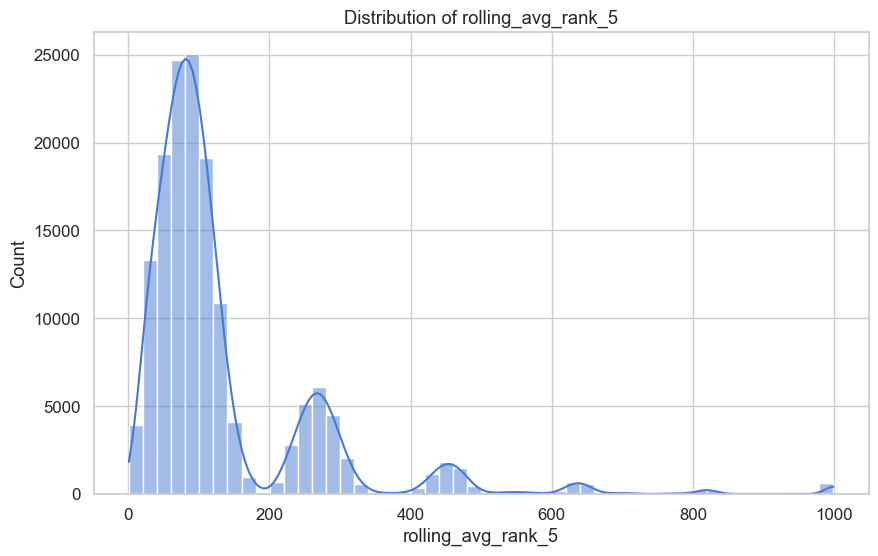

rolling_avg_rank_5 statistics:
Mean: 133.79, Median: 92.20, Min: 1.0, Max: 999.0, Std: 130.43
rolling_avg_rank_5 ranges widely and indicates recent performance trends.



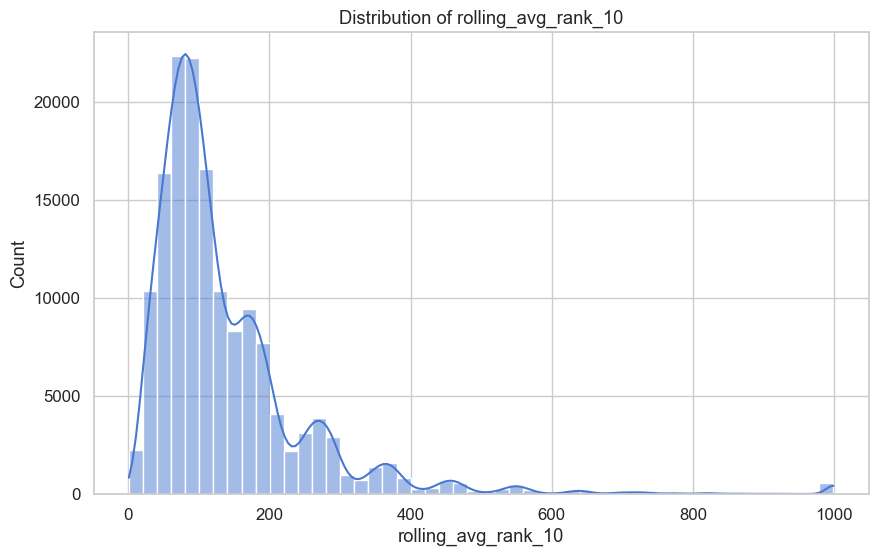

rolling_avg_rank_10 statistics:
Mean: 136.77, Median: 103.30, Min: 1.0, Max: 999.0, Std: 113.16
rolling_avg_rank_10 ranges widely and indicates recent performance trends.



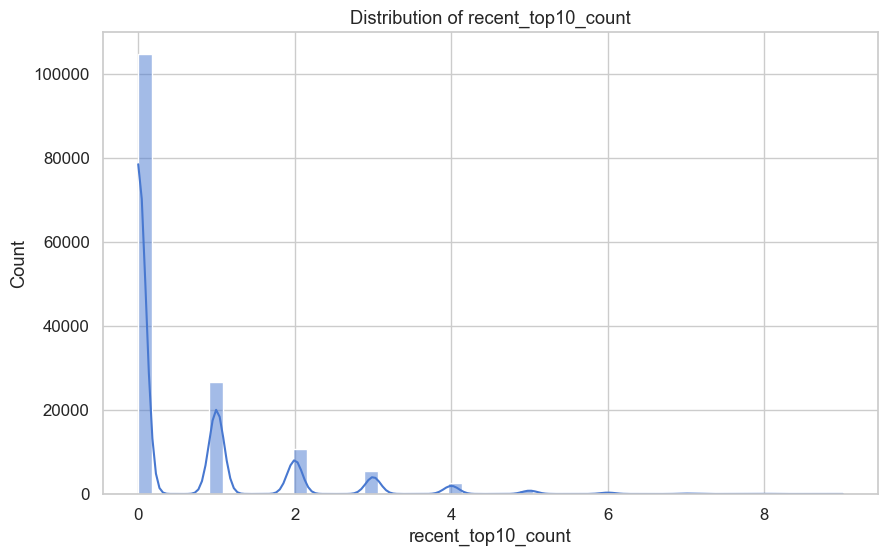

recent_top10_count statistics:
Mean: 0.55, Median: 0.00, Min: 0.0, Max: 9.0, Std: 1.04
recent_top10_count is skewed towards 0, reflecting few top-10 finishes recently.



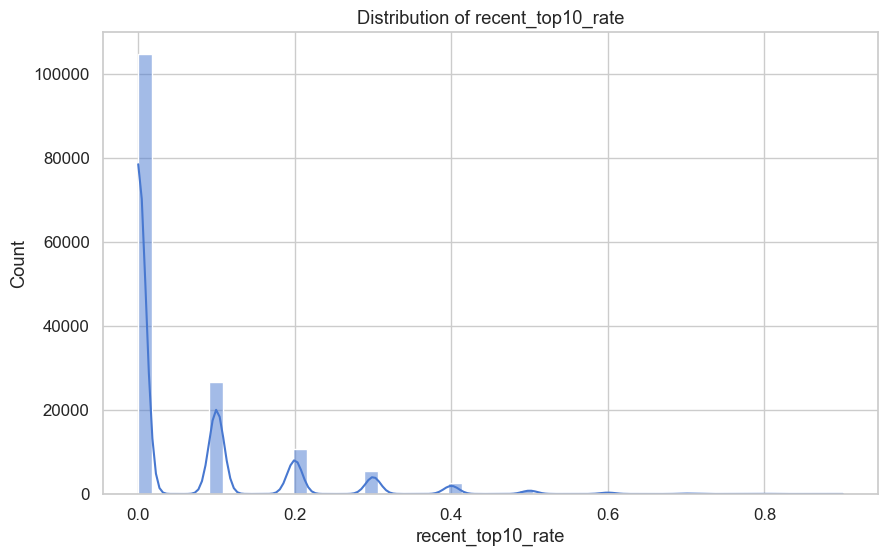

recent_top10_rate statistics:
Mean: 0.06, Median: 0.00, Min: 0.0, Max: 0.9, Std: 0.10
recent_top10_rate is skewed towards 0, reflecting few top-10 finishes recently.



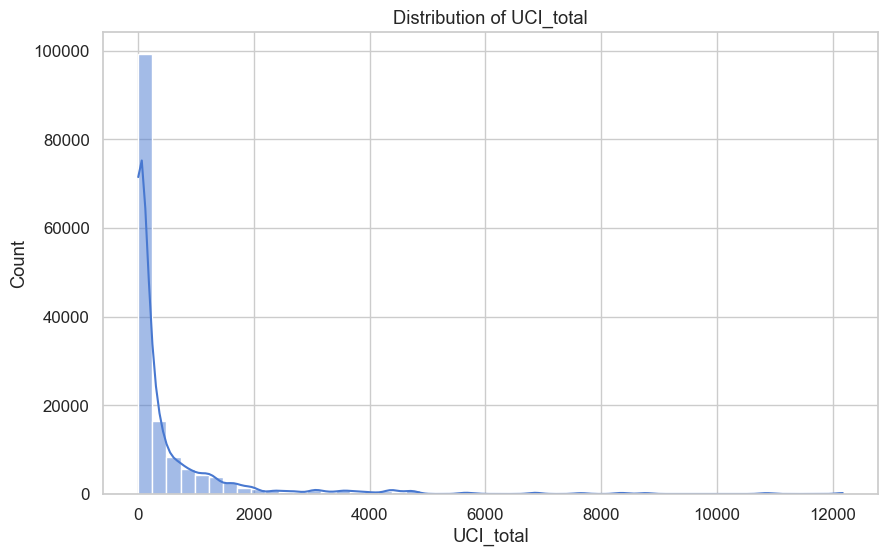

UCI_total statistics:
Mean: 524.95, Median: 91.00, Min: 0.0, Max: 12177.0, Std: 1207.99
UCI_total shows point accumulation; some riders have very high max values indicating elite performance.



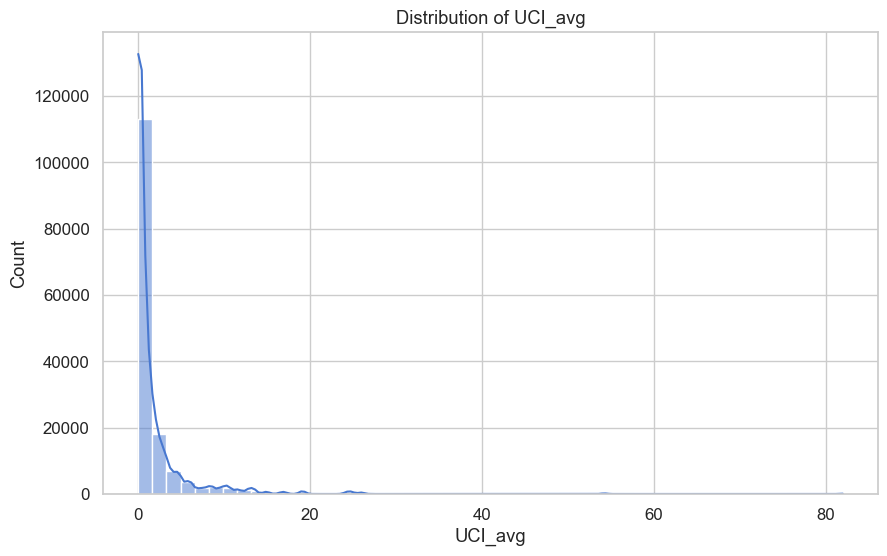

UCI_avg statistics:
Mean: 1.75, Median: 0.47, Min: 0.0, Max: 82.0, Std: 3.83
UCI_avg shows point accumulation; some riders have very high max values indicating elite performance.



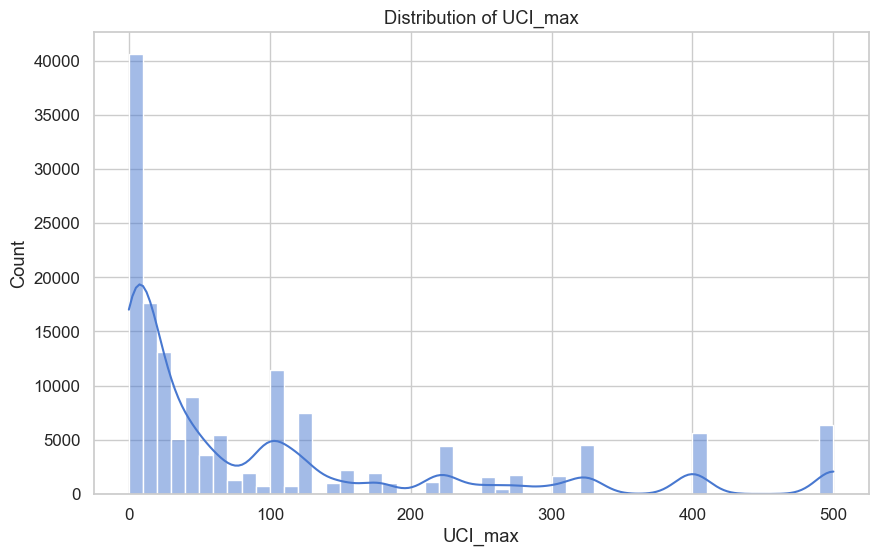

UCI_max statistics:
Mean: 96.89, Median: 35.00, Min: 0.0, Max: 500.0, Std: 133.62
UCI_max shows point accumulation; some riders have very high max values indicating elite performance.



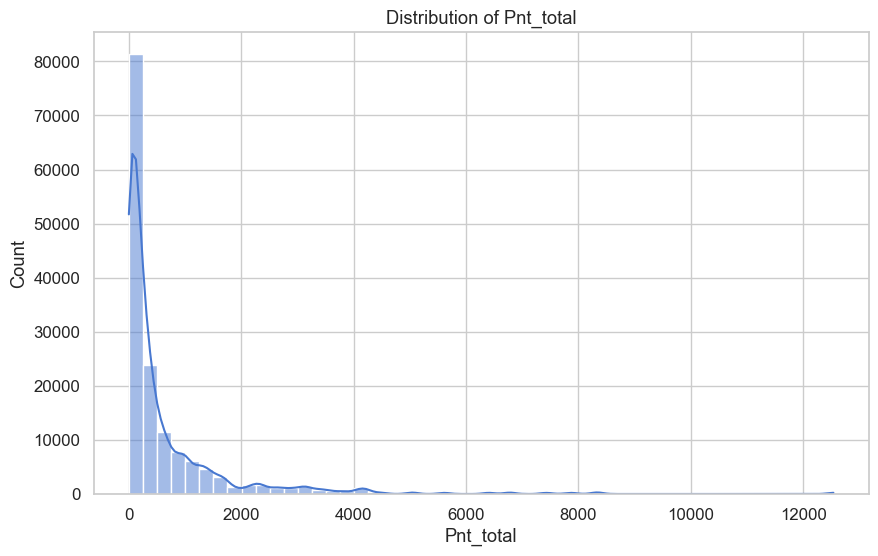

Pnt_total statistics:
Mean: 634.35, Median: 229.00, Min: 0.0, Max: 12538.0, Std: 1147.98
Pnt_total shows point accumulation; some riders have very high max values indicating elite performance.



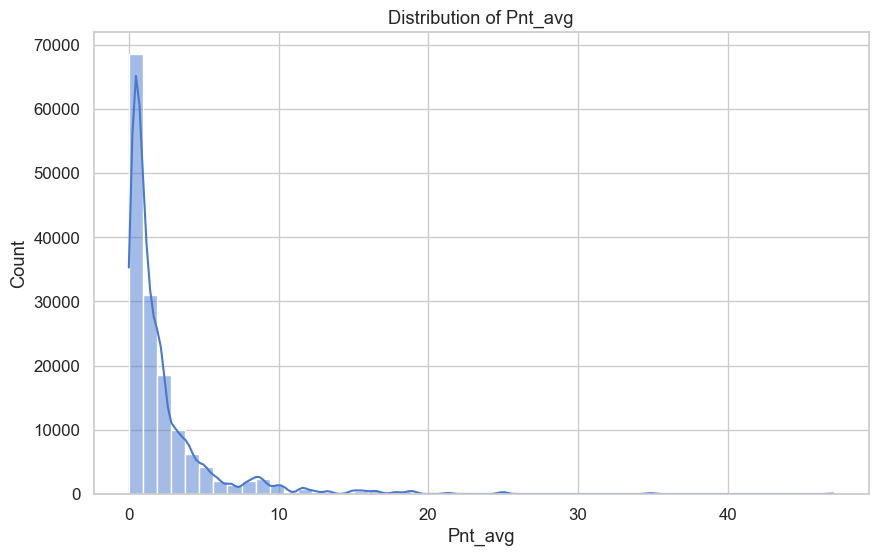

Pnt_avg statistics:
Mean: 2.20, Median: 1.11, Min: 0.0, Max: 47.0566037735849, Std: 3.22
Pnt_avg shows point accumulation; some riders have very high max values indicating elite performance.



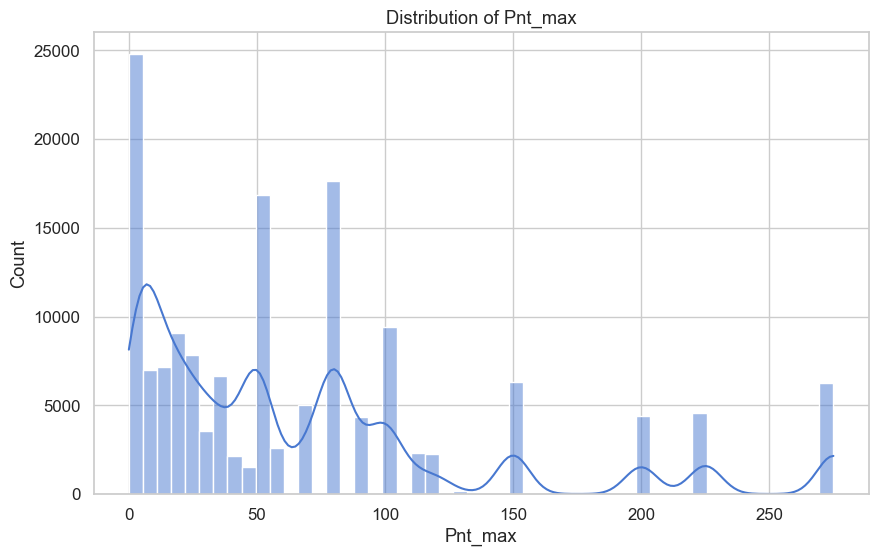

Pnt_max statistics:
Mean: 68.00, Median: 50.00, Min: 0.0, Max: 275.0, Std: 69.29
Pnt_max shows point accumulation; some riders have very high max values indicating elite performance.



In [15]:
plot_cols = ['Age','age_at_race','Length_km','Time_sec','Timelag_sec','Rnk_clean',
             'rolling_avg_rank_5','rolling_avg_rank_10','recent_top10_count','recent_top10_rate',
             'UCI_total','UCI_avg','UCI_max','Pnt_total','Pnt_avg','Pnt_max']

for col in plot_cols:
    plt.figure()
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    
    desc = df[col].describe()
    print(f"{col} statistics:")
    print(f"Mean: {desc['mean']:.2f}, Median: {desc['50%']:.2f}, Min: {desc['min']}, Max: {desc['max']}, Std: {desc['std']:.2f}")
    
    # Observations in words
    if col in ['Age','age_at_race']:
        print(f"Most riders are between 18 and 40 years old.\n")
    elif col == 'Length_km':
        print(f"Stage lengths vary widely, from {desc['min']} km to {desc['max']} km, mean {desc['mean']:.1f} km.\n")
    elif col in ['Time_sec','Timelag_sec']:
        print(f"Time distributions have long tails; median is {desc['50%']:.0f} sec, mean {desc['mean']:.0f} sec.\n")
    elif col == 'Rnk_clean':
        print(f"Ranking shows a heavy right tail; most riders are below {desc['50%']:.0f}.\n")
    elif 'rolling_avg_rank' in col:
        print(f"{col} ranges widely and indicates recent performance trends.\n")
    elif 'recent_top10' in col:
        print(f"{col} is skewed towards 0, reflecting few top-10 finishes recently.\n")
    elif 'UCI' in col or 'Pnt' in col:
        print(f"{col} shows point accumulation; some riders have very high max values indicating elite performance.\n")
    else:
        print("\n")

## Correlation Heatmap

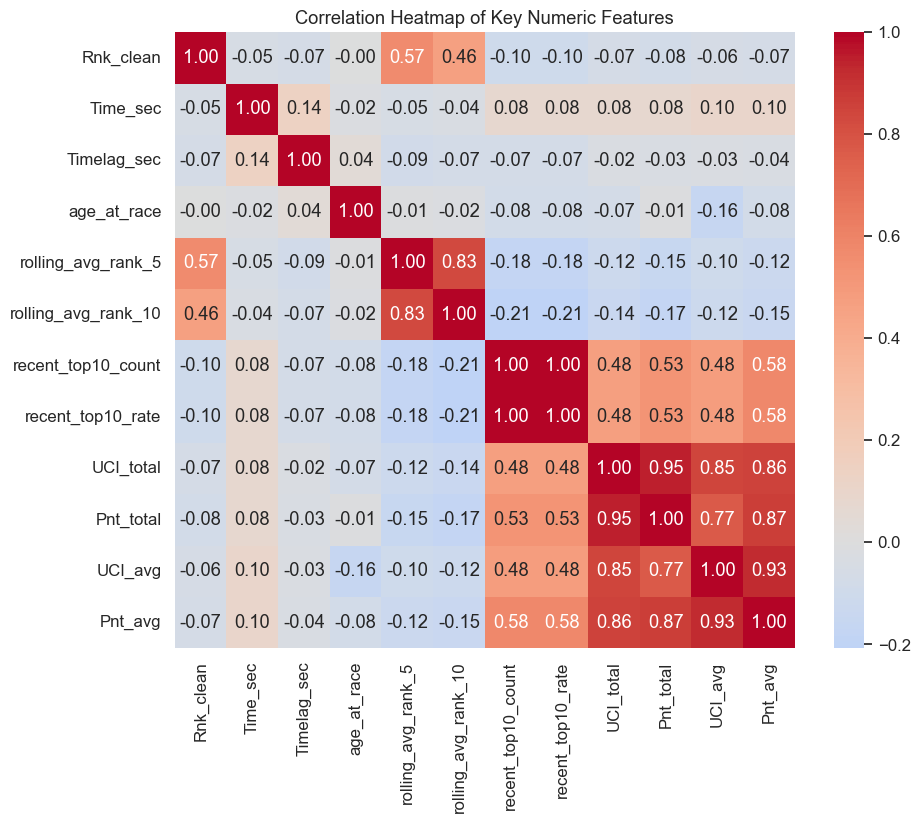

In [19]:
selected_cols = ['Rnk_clean','Time_sec','Timelag_sec','age_at_race',
                 'rolling_avg_rank_5','rolling_avg_rank_10','recent_top10_count','recent_top10_rate',
                 'UCI_total','Pnt_total','UCI_avg','Pnt_avg']

plt.figure(figsize=(10,8))
corr = df[selected_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Numeric Features")
plt.show()


Observations:
- `Rnk_clean` correlates strongly with rolling average ranks.
- `Time_sec` and `Timelag_sec` correlate moderately with ranking.
- UCI points and race points correlate with each other and with rank metrics.

## Categorical Features Analysis

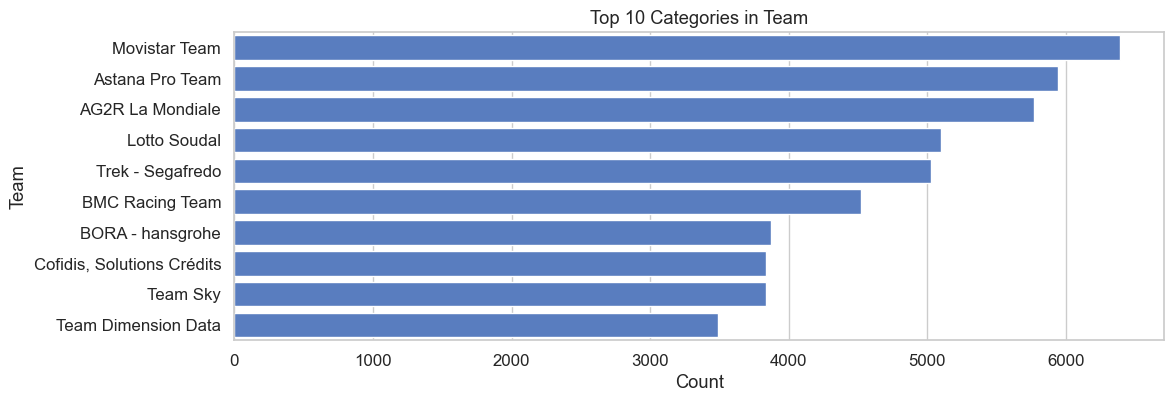

Top 10 Team counts:


Team
Movistar Team                 6391
Astana Pro Team               5943
AG2R La Mondiale              5773
Lotto Soudal                  5096
Trek - Segafredo              5024
BMC Racing Team               4523
BORA - hansgrohe              3869
Cofidis, Solutions Crédits    3838
Team Sky                      3833
Team Dimension Data           3493
Name: count, dtype: int64

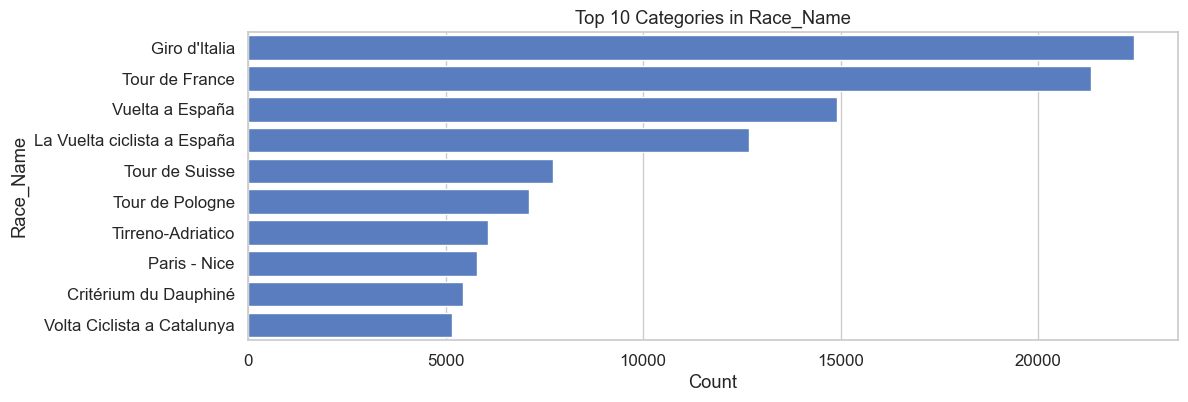

Top 10 Race_Name counts:


Race_Name
Giro d'Italia                  22420
Tour de France                 21348
Vuelta a España                14916
La Vuelta ciclista a España    12690
Tour de Suisse                  7724
Tour de Pologne                 7117
Tirreno-Adriatico               6071
Paris - Nice                    5807
Critérium du Dauphiné           5452
Volta Ciclista a Catalunya      5162
Name: count, dtype: int64

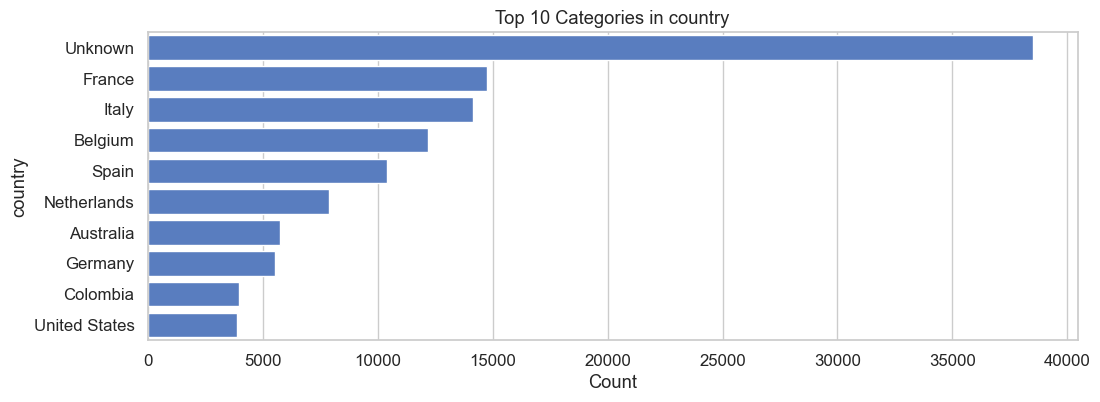

Top 10 country counts:


country
Unknown          38517
France           14745
Italy            14158
Belgium          12178
Spain            10415
Netherlands       7899
Australia         5750
Germany           5557
Colombia          3989
United States     3871
Name: count, dtype: int64

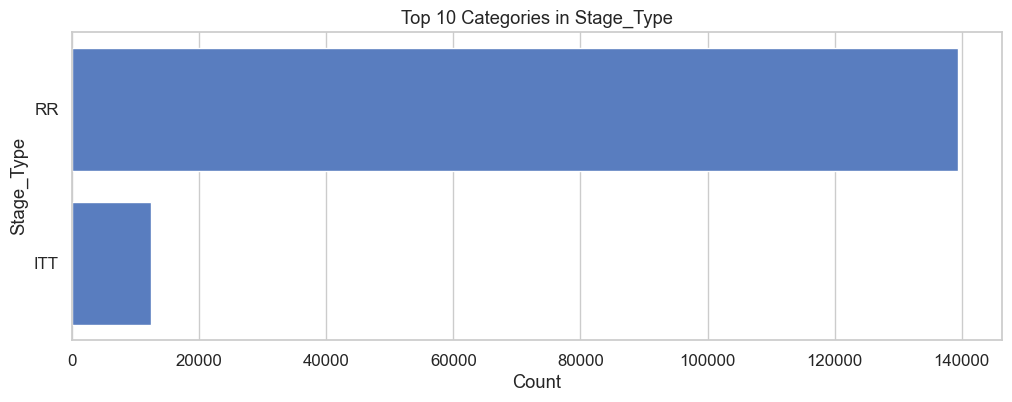

Top 10 Stage_Type counts:


Stage_Type
RR     139368
ITT     12378
Name: count, dtype: int64

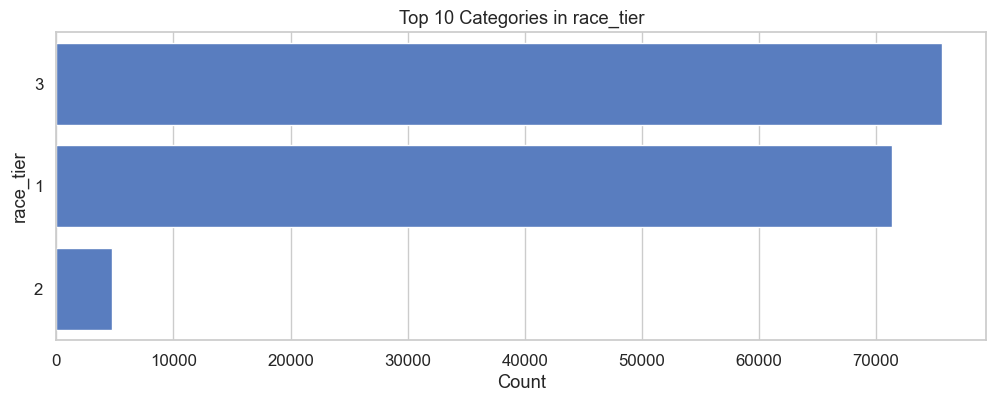

Top 10 race_tier counts:


race_tier
3    75652
1    71374
2     4720
Name: count, dtype: int64

In [17]:
cat_cols = ['Team','Race_Name','country','Stage_Type','race_tier']

for col in cat_cols:
    plt.figure(figsize=(12,4))
    top10 = df[col].value_counts().index[:10]
    sns.countplot(y=col, data=df, order=top10)
    plt.title(f"Top 10 Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()
    
    top_counts = df[col].value_counts().head(10)
    print(f"Top 10 {col} counts:")
    display(top_counts)
    print("\n")

Observations:
- Teams: most common teams dominate the dataset.
- Races: Tour de France, Vuelta a España, and Giro d’Italia are the most frequent.
- Countries: Italy, France, Spain, and Belgium dominate.
- Stage types: majority are road races (`RR`), few time trials or sprints.
- Race tiers: mostly Tier 2 events.

## Next Steps
- Feature engineering: age groups, normalized metrics.
- Explore top riders' historical performance.
- Prepare data for modeling: handle imbalance, scale features.
- Consider advanced visualization: top riders by UCI points over time, performance trends.